# Multiclass Classification Practice: Voter Data

## Setup

*Same voter data setup as notebooks 18–21.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
import warnings

warnings.filterwarnings('ignore')
np.random.seed(4025)

# Load and clean
voter_url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/non-voters/nonvoters_data.csv'
voter_raw = pd.read_csv(voter_url)

voter_clean = voter_raw.drop(columns=['RespId', 'weight', 'Q1']).copy()
voter_clean['educ'] = pd.Categorical(voter_clean['educ'],
    categories=['High school or less', 'Some college', 'College'], ordered=True)
voter_clean['income_cat'] = pd.Categorical(voter_clean['income_cat'],
    categories=['Less than $40k', '$40-75k ', '$75-125k', '$125k or more'], ordered=True)
voter_clean['voter_category'] = pd.Categorical(voter_clean['voter_category'],
    categories=['rarely/never', 'sporadic', 'always'], ordered=False)

voter_clean = voter_clean[voter_clean['Q22'] != 5].copy()
voter_clean['Q22'] = voter_clean['Q22'].fillna('Not Asked').astype(str)

for c in [f'Q28_{i}' for i in range(1, 9)]:
    voter_clean[c] = voter_clean[c].replace(-1.0, 0).fillna('Not Asked').astype(str)
for c in [f'Q29_{i}' for i in range(1, 11)]:
    voter_clean[c] = voter_clean[c].replace(-1.0, 0).fillna('Not Asked').astype(str)

def _party_id(row):
    q31, q32, q33 = row['Q31'], row['Q32'], row['Q33']
    if   q31 == 1: return 'Strong Republican'
    elif q31 == 2: return 'Republican'
    elif q32 == 1: return 'Strong Democrat'
    elif q32 == 2: return 'Democrat'
    elif q33 == 1: return 'Lean Republican'
    elif q33 == 2: return 'Lean Democrat'
    else:          return 'Other'

voter_clean['Party_ID'] = voter_clean.apply(_party_id, axis=1)
party_order = ['Strong Republican', 'Republican', 'Lean Republican',
               'Other', 'Lean Democrat', 'Democrat', 'Strong Democrat']
voter_clean['Party_ID'] = pd.Categorical(voter_clean['Party_ID'],
                                         categories=party_order, ordered=True)
voter_clean = voter_clean.drop(columns=['Q31', 'Q32', 'Q33'])

for c in voter_clean.columns:
    if c != 'ppage' and voter_clean[c].dtype in ['float64', 'int64']:
        voter_clean[c] = voter_clean[c].replace(-1, np.nan)

X_voter = voter_clean.drop(columns=['voter_category'])
y_voter = voter_clean['voter_category']
classes = list(y_voter.cat.categories)  # ['rarely/never', 'sporadic', 'always']

X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter, test_size=0.3, stratify=y_voter, random_state=4025)

ordered_cat_cols = ['educ', 'income_cat', 'Party_ID']
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
nom_cols = [c for c in X_train.columns
            if c not in ordered_cat_cols and c not in num_cols]

preproc_voter = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median'))]), num_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), ordered_cat_cols),
    ('nom', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), nom_cols),
], remainder='drop')

print(f"Training: {X_train.shape[0]} obs  |  Test: {X_test.shape[0]} obs")
print(f"Classes: {classes}")

Training: 4071 obs  |  Test: 1746 obs
Classes: ['rarely/never', 'sporadic', 'always']


## Visualize Response

How balanced are the three voter categories in the training set?

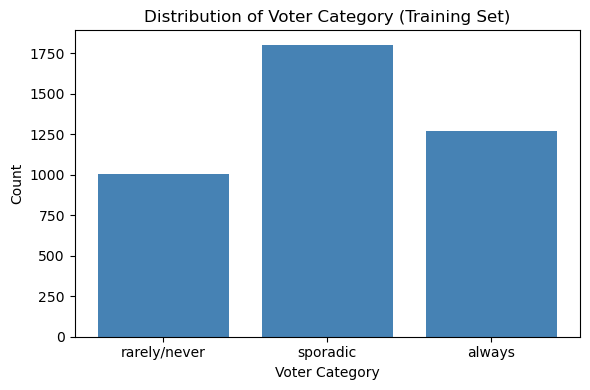

In [2]:
counts = y_train.value_counts().reindex(classes)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color='steelblue')
ax.set_xlabel('Voter Category')
ax.set_ylabel('Count')
ax.set_title('Distribution of Voter Category (Training Set)')
plt.tight_layout()
plt.show()

## Define and Fit Multinomial Logistic Regression

Multinomial logistic regression models log-odds of each class relative to a reference class.
We use the `saga` solver which supports L1 regularization for multiclass problems.
`C` is the inverse regularization strength — larger C = less regularization.

In [4]:
mn_pipe = Pipeline([
    ('preproc', preproc_voter),
    ('mn', LogisticRegression(
        C=200,
        solver='saga',
        max_iter=500,
        random_state=4025
    ))
])

mn_pipe.fit(X_train, y_train)
print(f"Train Accuracy: {accuracy_score(y_train, mn_pipe.predict(X_train)):.3f}")
print(f"Test Accuracy:  {accuracy_score(y_test,  mn_pipe.predict(X_test)):.3f}")

Train Accuracy: 0.636
Test Accuracy:  0.590


## Predictions

The model outputs three probability columns — one per class. Each row sums to 1.
The predicted class is the one with the highest probability.

In [ ]:
proba = mn_pipe.predict_proba(X_test)
proba

array([[1.17474606e-01, 3.90574732e-01, 4.91950662e-01],
       [1.05942578e-01, 7.10547104e-01, 1.83510318e-01],
       [3.33826783e-01, 3.16119909e-01, 3.50053308e-01],
       ...,
       [6.98945127e-04, 9.94941157e-01, 4.35989759e-03],
       [3.85663827e-01, 9.70948359e-02, 5.17241337e-01],
       [6.87887798e-01, 4.29562545e-02, 2.69155947e-01]], shape=(1746, 3))

In [8]:
preds = mn_pipe.predict(X_test)
preds

array(['sporadic', 'rarely/never', 'sporadic', ..., 'rarely/never',
       'sporadic', 'always'], shape=(1746,), dtype=object)

In [9]:

pred_df = pd.DataFrame(proba, columns=[f'P({c})' for c in classes])
pred_df['predicted'] = preds
pred_df['actual'] = y_test.values

# Show a random sample of 10 rows
pred_df.sample(10, random_state=4025)

,P(rarely/never),P(sporadic),P(always),predicted,actual
172,0.121116,0.514183,0.364701,rarely/never,sporadic
500,0.299785,0.074449,0.625766,sporadic,sporadic
479,0.005793,0.972623,0.021584,rarely/never,rarely/never
934,0.572564,0.023685,0.403751,always,sporadic
530,0.519544,0.039284,0.441172,always,always
1555,0.131894,0.419992,0.448113,sporadic,sporadic
1045,0.489456,0.045355,0.465189,always,always
1258,0.565219,0.068371,0.366410,always,always
1082,0.217215,0.107874,0.674911,sporadic,sporadic
1349,0.223152,0.287633,0.489215,sporadic,always


## Confusion Matrix

Rows = true class, columns = predicted class. The diagonal = correct predictions.

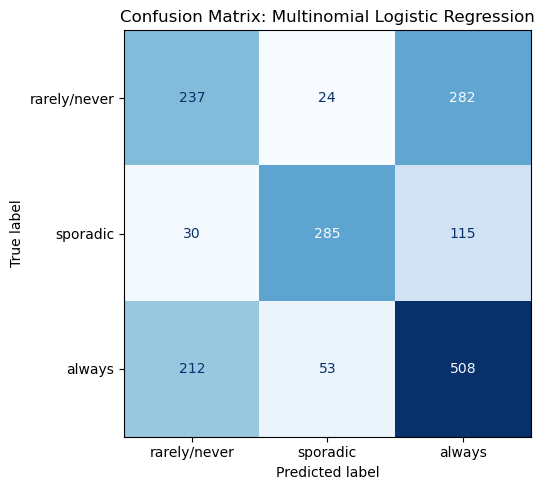

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    mn_pipe, X_test, y_test,
    display_labels=classes,
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Confusion Matrix: Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

## Per-Class Recall

One-vs-all recall: for each class, treat it as "positive" and all others as "negative".
This tells us how well the model identifies each class individually.

In [ ]:
# Compute one-vs-all recall using only addition and division

# Rarely/never
237/(237 + 24 + 282)

# Sporadic


# Always



In [ ]:
# Compute one-vs all precision using only addition and division (paste your results in Teams)

# Rarely/never


# Sporadic


# Always

In [13]:
print("Per-class recall (one-vs-all):")
per_class_recall = recall_score(y_test, preds, labels=classes, average=None)
# for cls, rec in zip(classes, per_class_recall):
#     print(f"  {cls}: {rec:.3f}")

# print("\nFull classification report:")
# print(classification_report(y_test, preds, target_names=classes))
per_class_recall

Per-class recall (one-vs-all):


array([0.6627907 , 0.65717982, 0.43646409])

## Macro Averaging

Macro-averaging computes the metric for each class independently, then averages them **equally**.
Every class gets equal weight regardless of how many observations it contains.

In [ ]:
print("Macro-averaged metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, preds):.3f}")
print(f"  Precision: {precision_score(y_test, preds, average='macro'):.3f}")
print(f"  Recall:    {recall_score(y_test, preds, average='macro'):.3f}")
print(f"  F1:        {f1_score(y_test, preds, average='macro'):.3f}")

## Macro-Weighted Averaging

Macro-weighted averaging weights each class by the number of true observations in that class.
Larger classes have more influence on the final metric.

In [ ]:
print("Macro-weighted metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, preds):.3f}")
print(f"  Precision: {precision_score(y_test, preds, average='weighted'):.3f}")
print(f"  Recall:    {recall_score(y_test, preds, average='weighted'):.3f}")
print(f"  F1:        {f1_score(y_test, preds, average='weighted'):.3f}")

## Micro Averaging

Micro-averaging pools all TP, FP, and FN counts across classes before computing the metric.
For standard multiclass classification (not multi-label), micro recall = micro precision = accuracy.

In [ ]:
print("Micro-averaged metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, preds):.3f}")
print(f"  Precision: {precision_score(y_test, preds, average='micro'):.3f}")
print(f"  Recall:    {recall_score(y_test, preds, average='micro'):.3f}")
print(f"  F1:        {f1_score(y_test, preds, average='micro'):.3f}")
print("\nNote: micro precision = micro recall = micro F1 = accuracy for multiclass.")

## ROC Curves (One-vs-All)

For each class, plot the ROC curve treating that class as "positive" vs. all others.
The area under each curve tells us how well the model separates that class from the rest.

In [ ]:
# Binarize the test labels: one column per class
y_test_bin = label_binarize(y_test, classes=classes)
proba_arr  = mn_pipe.predict_proba(X_test)

colors = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, color) in enumerate(zip(classes, colors)):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], proba_arr[:, i],
        name=cls, color=color, ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_title('One-vs-All ROC Curves: Multinomial Logistic Regression')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## AUC Variants

Three ways to summarize multiclass AUC into a single number:
- **Macro OVR**: average one-vs-all AUC equally across classes
- **Weighted OVR**: weight one-vs-all AUC by class size
- **Hand and Till (OVO)**: average pairwise AUC across all class pairs

In [ ]:
auc_macro    = roc_auc_score(y_test, proba_arr, multi_class='ovr', average='macro')
auc_weighted = roc_auc_score(y_test, proba_arr, multi_class='ovr', average='weighted')
auc_ovo      = roc_auc_score(y_test, proba_arr, multi_class='ovo', average='macro')

auc_summary = pd.DataFrame({
    'Method':   ['Macro OVR', 'Weighted OVR', 'Hand and Till (OVO)'],
    'AUC':      [auc_macro, auc_weighted, auc_ovo],
    'Weighting': ['Equal per class', 'Proportional to class size', 'Equal per class pair']
})
auc_summary